Загрузка Excel файла: Bank_Transaction_Fraud_Detection.xlsx
Данные успешно загружены! Размер: 200000 строк, 24 столбцов
Размер данных после очистки: 195990 записей

РИСУНОК 1: Гистограммы числовых признаков


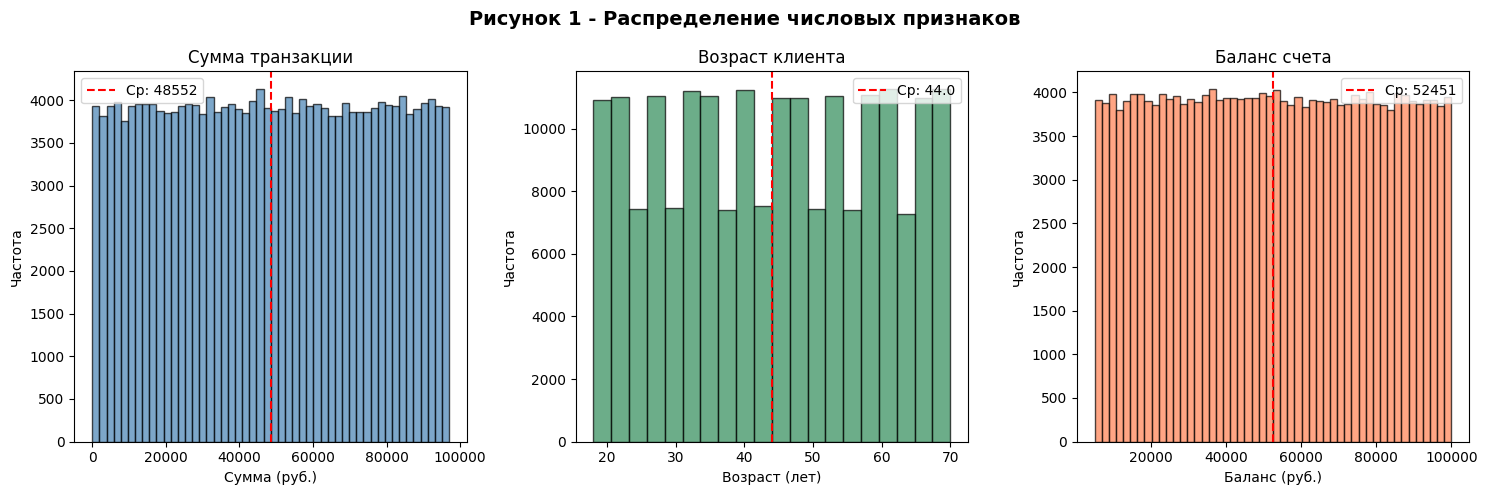


РИСУНОК 2: Scatterplot суммы от баланса


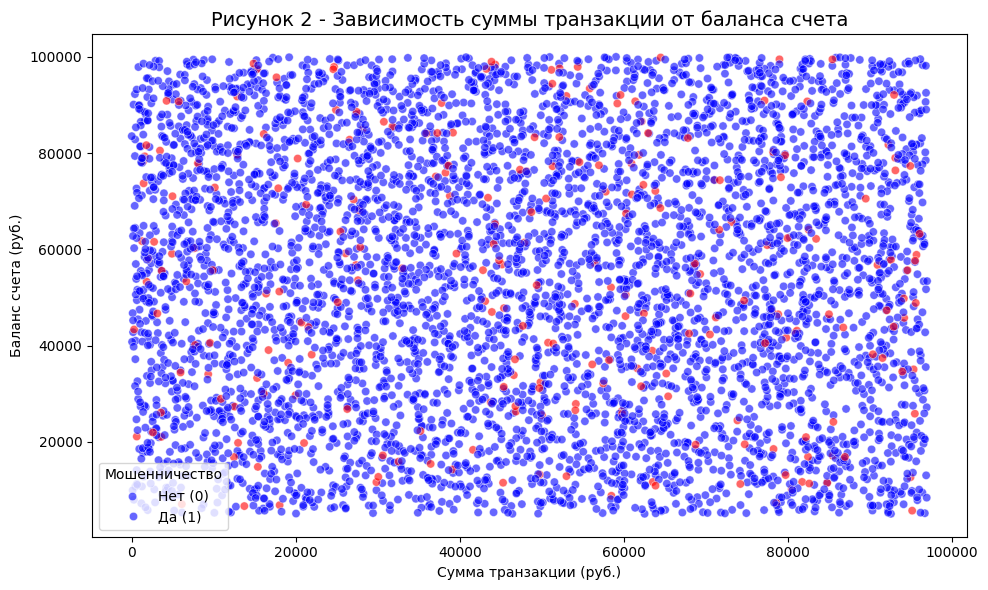


РИСУНОК 3: Boxplot сумм по типам счета


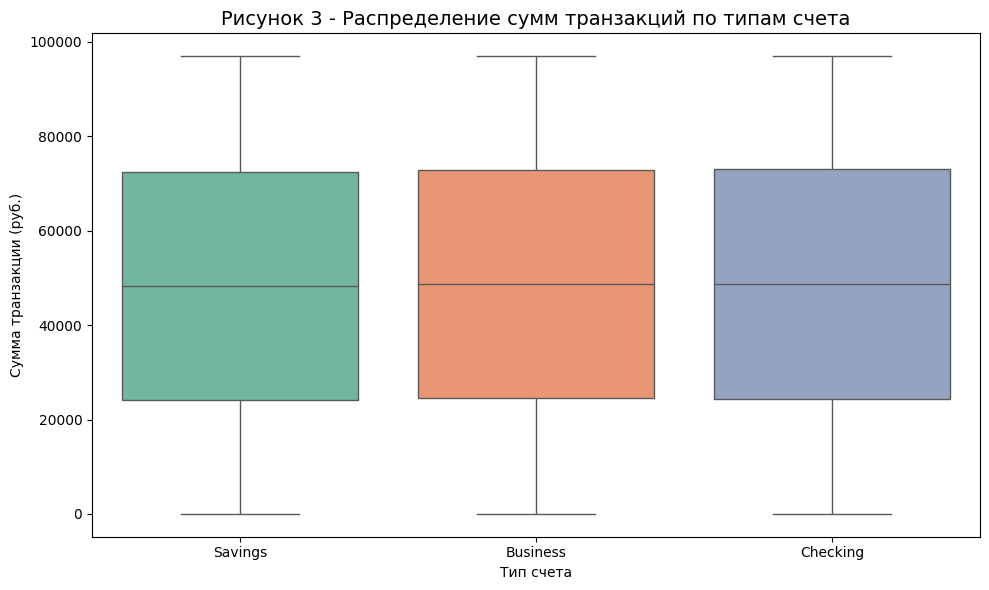


РИСУНОК 4: KDE Plot возраста по признаку мошенничества


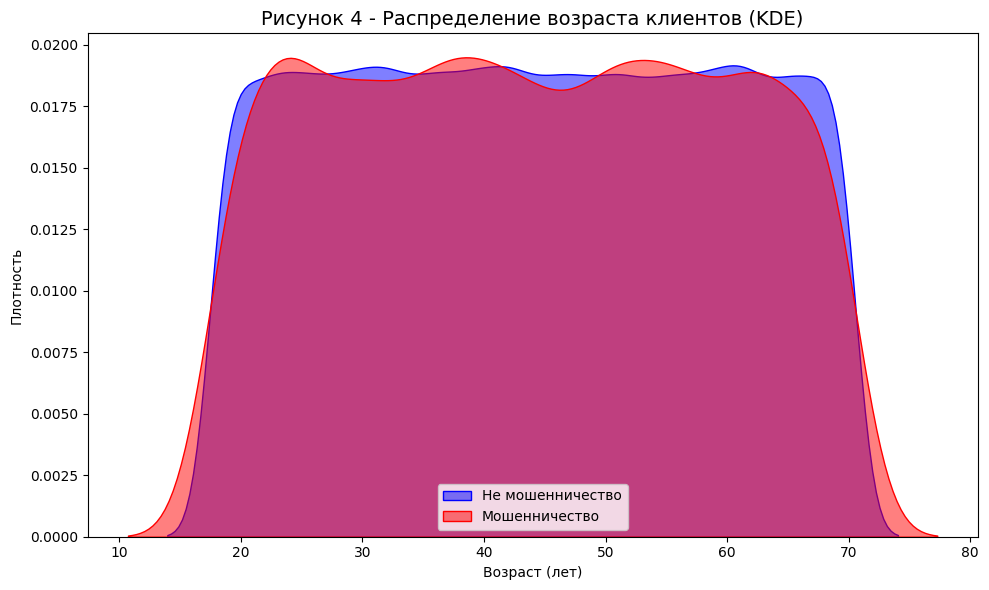


РИСУНОК 5: Интерактивный Scatter plot (Plotly)



РИСУНОК 6: Интерактивный Box plot (Plotly)



РИСУНОК 7: Тепловая карта корреляции


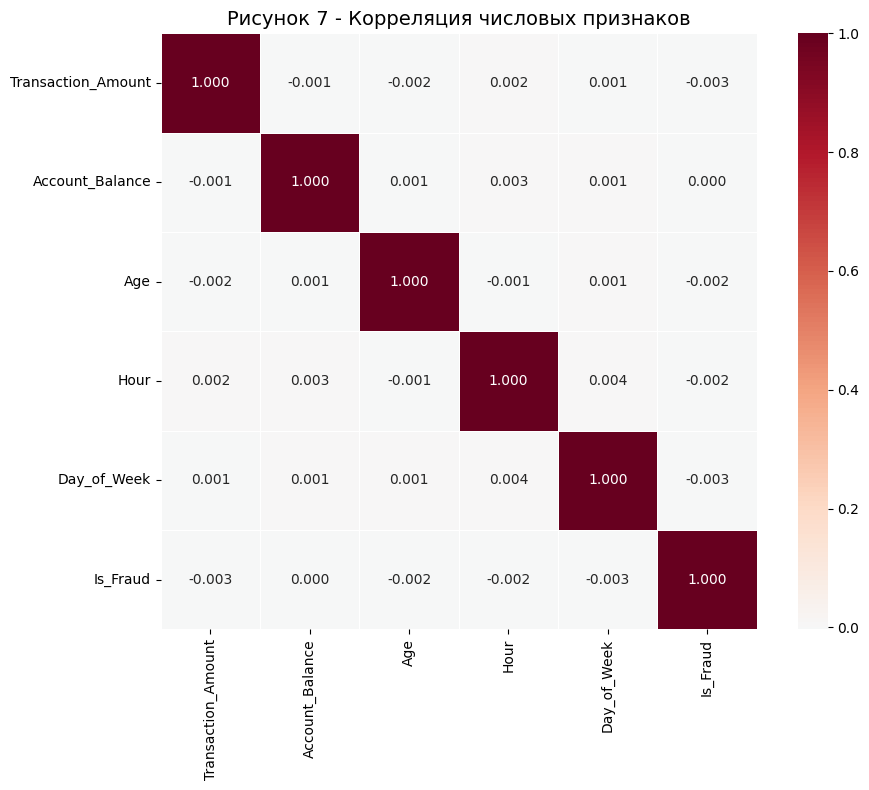


РИСУНОК 8: Тепловая карта активности (часы × дни недели)


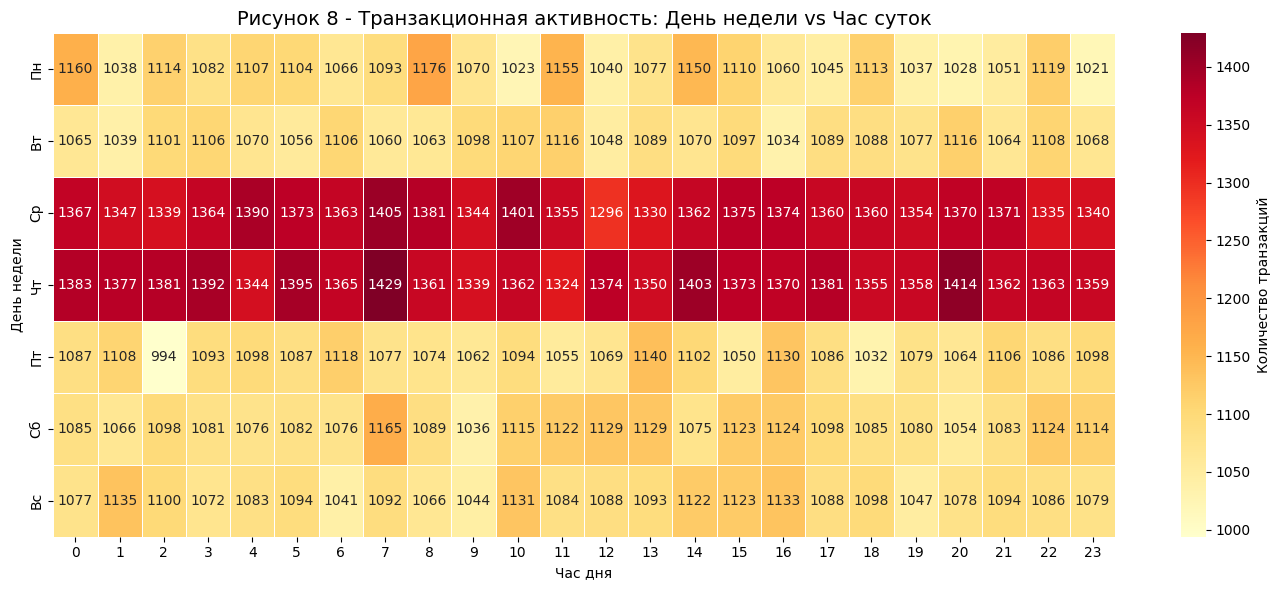


РИСУНОК 9: Гистограммы Hour и Day_of_Week


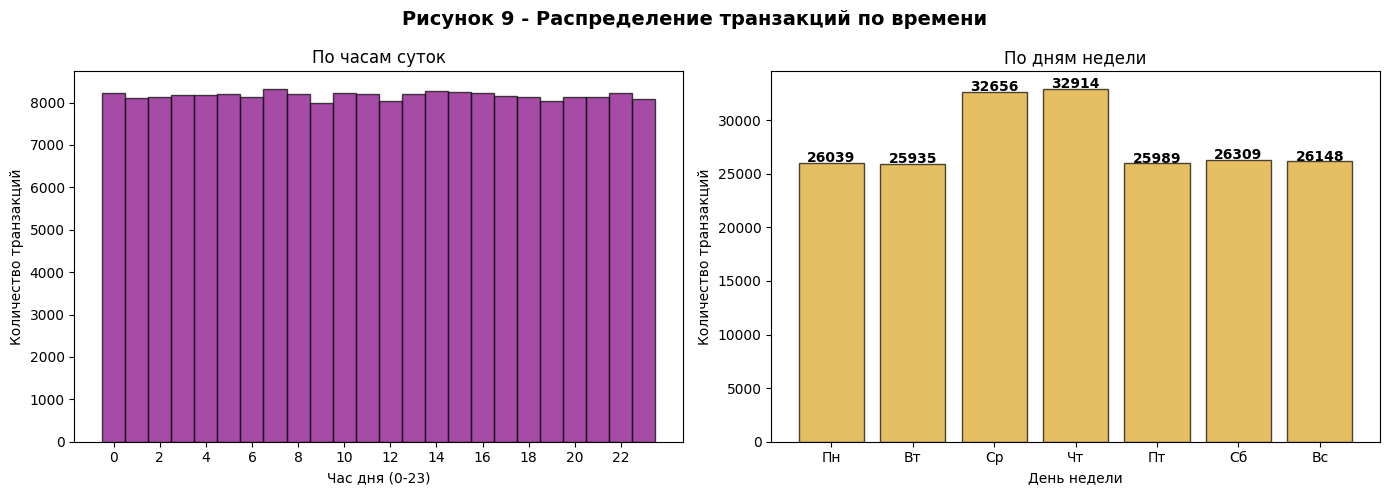


РИСУНОК 10: Круговая диаграмма Is_Fraud


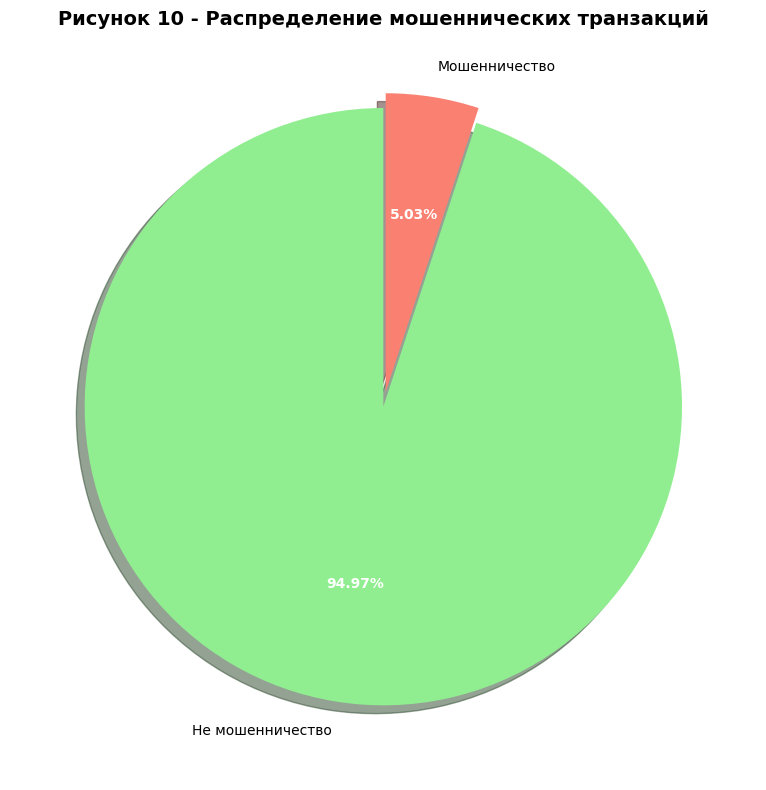


РИСУНОК 11: Столбчатая диаграмма Risk_Profile


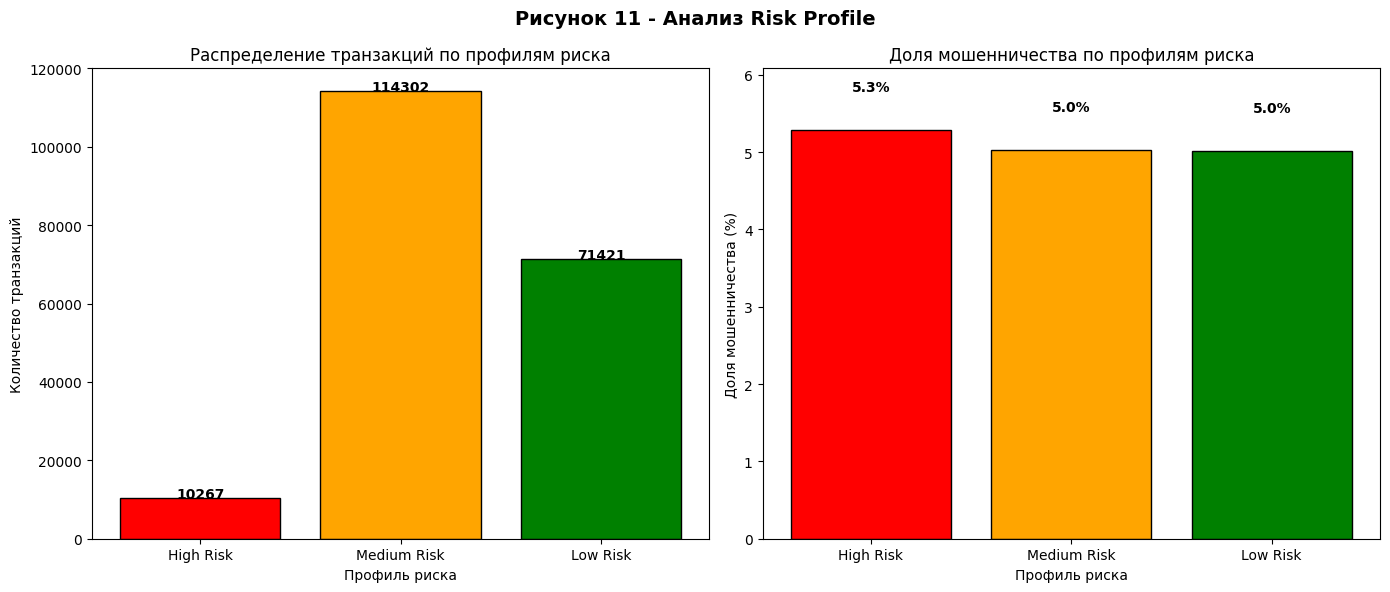

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ
# ============================================================================

def load_data(file_path):
    if file_path.endswith('.csv'):
        print(f"Загрузка CSV файла: {file_path}")
        return pd.read_csv(file_path)
    elif file_path.endswith(('.xlsx', '.xls')):
        print(f"Загрузка Excel файла: {file_path}")
        return pd.read_excel(file_path, engine='openpyxl')
    else:
        raise ValueError("Неподдерживаемый формат файла. Используйте .csv или .xlsx")

file_path = 'Bank_Transaction_Fraud_Detection.xlsx'

try:
    df = load_data(file_path)
    print(f"Данные успешно загружены! Размер: {df.shape[0]} строк, {df.shape[1]} столбцов")
except FileNotFoundError:
    print(f"Файл {file_path} не найден. Загрузка CSV...")
    df = pd.read_csv('Bank_Transaction_Fraud_Detection.csv')
    print(f"CSV загружен! Размер: {df.shape[0]} строк, {df.shape[1]} столбцов")

# Преобразование типов
df['Transaction_Amount'] = pd.to_numeric(df['Transaction_Amount'], errors='coerce')
df['Account_Balance'] = pd.to_numeric(df['Account_Balance'], errors='coerce')
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Is_Fraud'] = pd.to_numeric(df['Is_Fraud'], errors='coerce')

# Извлечение временных признаков
df['Hour'] = pd.to_datetime(df['Transaction_Time'], format='%H:%M:%S', errors='coerce').dt.hour
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'], format='%d-%m-%Y', errors='coerce')
df['Day_of_Week'] = df['Transaction_Date'].dt.dayofweek

# Удаление NaN
df_clean = df.dropna(subset=['Transaction_Amount', 'Account_Balance', 'Age', 'Hour', 'Day_of_Week'])

# Фильтрация выбросов для наглядности (верхние 2%)
upper_bound = df_clean['Transaction_Amount'].quantile(0.98)
df_viz = df_clean[df_clean['Transaction_Amount'] <= upper_bound].copy()

# Подготовка названий дней недели
days_map = {0: 'Пн', 1: 'Вт', 2: 'Ср', 3: 'Чт', 4: 'Пт', 5: 'Сб', 6: 'Вс'}
df_viz['Day_Name'] = df_viz['Day_of_Week'].map(days_map)

print(f"Размер данных после очистки: {len(df_viz)} записей")

# ============================================================================
# РИСУНОК 1: Гистограммы Transaction_Amount, Age, Account_Balance
# ============================================================================
print("\n" + "="*80)
print("РИСУНОК 1: Гистограммы числовых признаков")
print("="*80)

fig1, axes1 = plt.subplots(1, 3, figsize=(15, 5))
fig1.suptitle('Рисунок 1 - Распределение числовых признаков', fontsize=14, fontweight='bold')

# Transaction_Amount
axes1[0].hist(df_viz['Transaction_Amount'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes1[0].set_title('Сумма транзакции')
axes1[0].set_xlabel('Сумма (руб.)')
axes1[0].set_ylabel('Частота')
axes1[0].axvline(df_viz['Transaction_Amount'].mean(), color='red', linestyle='--', label=f'Ср: {df_viz["Transaction_Amount"].mean():.0f}')
axes1[0].legend()

# Age
axes1[1].hist(df_viz['Age'], bins=20, color='seagreen', edgecolor='black', alpha=0.7)
axes1[1].set_title('Возраст клиента')
axes1[1].set_xlabel('Возраст (лет)')
axes1[1].set_ylabel('Частота')
axes1[1].axvline(df_viz['Age'].mean(), color='red', linestyle='--', label=f'Ср: {df_viz["Age"].mean():.1f}')
axes1[1].legend()

# Account_Balance
axes1[2].hist(df_viz['Account_Balance'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes1[2].set_title('Баланс счета')
axes1[2].set_xlabel('Баланс (руб.)')
axes1[2].set_ylabel('Частота')
axes1[2].axvline(df_viz['Account_Balance'].mean(), color='red', linestyle='--', label=f'Ср: {df_viz["Account_Balance"].mean():.0f}')
axes1[2].legend()

plt.tight_layout()
plt.savefig('figure1_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# РИСУНОК 2: Scatterplot: Transaction_Amount vs Account_Balance (цвет Is_Fraud)
# ============================================================================
print("\n" + "="*80)
print("РИСУНОК 2: Scatterplot суммы от баланса")
print("="*80)

fig2, ax2 = plt.subplots(figsize=(10, 6))
scatter = sns.scatterplot(
    data=df_viz.sample(min(5000, len(df_viz))),
    x='Transaction_Amount',
    y='Account_Balance',
    hue='Is_Fraud',
    alpha=0.6,
    palette={0: 'blue', 1: 'red'},
    ax=ax2
)
ax2.set_title('Рисунок 2 - Зависимость суммы транзакции от баланса счета', fontsize=14)
ax2.set_xlabel('Сумма транзакции (руб.)')
ax2.set_ylabel('Баланс счета (руб.)')
ax2.legend(title='Мошенничество', labels=['Нет (0)', 'Да (1)'])
plt.tight_layout()
plt.savefig('figure2_scatterplot.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# РИСУНОК 3: Boxplot: Transaction_Amount по Account_Type
# ============================================================================
print("\n" + "="*80)
print("РИСУНОК 3: Boxplot сумм по типам счета")
print("="*80)

fig3, ax3 = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_viz, x='Account_Type', y='Transaction_Amount', palette='Set2', ax=ax3)
ax3.set_title('Рисунок 3 - Распределение сумм транзакций по типам счета', fontsize=14)
ax3.set_xlabel('Тип счета')
ax3.set_ylabel('Сумма транзакции (руб.)')
plt.tight_layout()
plt.savefig('figure3_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# РИСУНОК 4: KDE Plot: Age по Is_Fraud
# ============================================================================
print("\n" + "="*80)
print("РИСУНОК 4: KDE Plot возраста по признаку мошенничества")
print("="*80)

fig4, ax4 = plt.subplots(figsize=(10, 6))
for fraud_val, color, label in [(0, 'blue', 'Не мошенничество'), (1, 'red', 'Мошенничество')]:
    subset = df_viz[df_viz['Is_Fraud'] == fraud_val]['Age'].dropna()
    sns.kdeplot(subset, fill=True, color=color, alpha=0.5, label=label, ax=ax4)
ax4.set_title('Рисунок 4 - Распределение возраста клиентов (KDE)', fontsize=14)
ax4.set_xlabel('Возраст (лет)')
ax4.set_ylabel('Плотность')
ax4.legend()
plt.tight_layout()
plt.savefig('figure4_kdeplot.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# РИСУНОК 5: Интерактивный Scatter plot (Plotly)
# ============================================================================
print("\n" + "="*80)
print("РИСУНОК 5: Интерактивный Scatter plot (Plotly)")
print("="*80)

fig5 = px.scatter(
    df_viz.sample(min(3000, len(df_viz))),
    x='Transaction_Amount',
    y='Account_Balance',
    color='Is_Fraud',
    size='Age',
    hover_data=['Customer_ID', 'Merchant_Category', 'Transaction_Type'],
    title='Рисунок 5 - Интерактивная диаграмма рассеяния: Сумма vs Баланс',
    labels={'Transaction_Amount': 'Сумма (руб.)', 'Account_Balance': 'Баланс (руб.)', 'Is_Fraud': 'Мошенничество'},
    color_continuous_scale=['blue', 'red'],
    opacity=0.7
)
fig5.update_layout(height=600, width=900)
fig5.write_html("figure5_interactive_scatter.html")
fig5.show()

# ============================================================================
# РИСУНОК 6: Интерактивный Box plot (Plotly)
# ============================================================================
print("\n" + "="*80)
print("РИСУНОК 6: Интерактивный Box plot (Plotly)")
print("="*80)

fig6 = px.box(
    df_viz,
    x='Account_Type',
    y='Transaction_Amount',
    color='Is_Fraud',
    title='Рисунок 6 - Интерактивный Box plot: суммы по типам счета',
    labels={'Account_Type': 'Тип счета', 'Transaction_Amount': 'Сумма (руб.)', 'Is_Fraud': 'Мошенничество'},
    points='all'
)
fig6.update_layout(height=500, width=900)
fig6.write_html("figure6_interactive_boxplot.html")
fig6.show()

# ============================================================================
# РИСУНОК 7: Тепловая карта корреляции числовых признаков
# ============================================================================
print("\n" + "="*80)
print("РИСУНОК 7: Тепловая карта корреляции")
print("="*80)

numeric_cols = ['Transaction_Amount', 'Account_Balance', 'Age', 'Hour', 'Day_of_Week', 'Is_Fraud']
corr_matrix = df_viz[numeric_cols].corr()

fig7, ax7 = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax7)
ax7.set_title('Рисунок 7 - Корреляция числовых признаков', fontsize=14)
plt.tight_layout()
plt.savefig('figure7_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Интерактивная версия тепловой карты
fig7_interactive = px.imshow(
    corr_matrix,
    text_auto=True,
    aspect='auto',
    color_continuous_scale='RdBu_r',
    title='Рисунок 7 (интерактивный) - Корреляция числовых признаков'
)
fig7_interactive.write_html("figure7_correlation_heatmap.html")
fig7_interactive.show()

# ============================================================================
# РИСУНОК 8: Тепловая карта активности (часы × дни недели)
# ============================================================================
print("\n" + "="*80)
print("РИСУНОК 8: Тепловая карта активности (часы × дни недели)")
print("="*80)

# Создание сводной таблицы
pivot_activity = df_viz.pivot_table(
    values='Transaction_ID',
    index='Day_Name',
    columns='Hour',
    aggfunc='count',
    fill_value=0
)
day_order = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
pivot_activity = pivot_activity.reindex(day_order)

fig8, ax8 = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot_activity, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, ax=ax8, cbar_kws={'label': 'Количество транзакций'})
ax8.set_title('Рисунок 8 - Транзакционная активность: День недели vs Час суток', fontsize=14)
ax8.set_xlabel('Час дня')
ax8.set_ylabel('День недели')
plt.tight_layout()
plt.savefig('figure8_activity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Интерактивная версия
fig8_interactive = px.imshow(
    pivot_activity,
    text_auto=True,
    aspect='auto',
    color_continuous_scale='YlOrRd',
    title='Рисунок 8 (интерактивный) - Активность по дням и часам',
    labels=dict(x='Час дня', y='День недели', color='Кол-во транзакций')
)
fig8_interactive.write_html("figure8_activity_heatmap.html")
fig8_interactive.show()

# ============================================================================
# РИСУНОК 9: Гистограммы Hour и Day_of_Week
# ============================================================================
print("\n" + "="*80)
print("РИСУНОК 9: Гистограммы Hour и Day_of_Week")
print("="*80)

fig9, axes9 = plt.subplots(1, 2, figsize=(14, 5))
fig9.suptitle('Рисунок 9 - Распределение транзакций по времени', fontsize=14, fontweight='bold')

# Гистограмма по часам
axes9[0].hist(df_viz['Hour'], bins=24, color='purple', edgecolor='black', alpha=0.7, range=(-0.5, 23.5))
axes9[0].set_title('По часам суток')
axes9[0].set_xlabel('Час дня (0-23)')
axes9[0].set_ylabel('Количество транзакций')
axes9[0].set_xticks(range(0, 24, 2))

# Гистограмма по дням недели
day_counts = df_viz['Day_Name'].value_counts()
day_counts = day_counts.reindex(day_order)
axes9[1].bar(day_counts.index, day_counts.values, color='goldenrod', edgecolor='black', alpha=0.7)
axes9[1].set_title('По дням недели')
axes9[1].set_xlabel('День недели')
axes9[1].set_ylabel('Количество транзакций')
for i, v in enumerate(day_counts.values):
    axes9[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('figure9_hour_day_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# РИСУНОК 10: Круговая диаграмма Is_Fraud
# ============================================================================
print("\n" + "="*80)
print("РИСУНОК 10: Круговая диаграмма Is_Fraud")
print("="*80)

fraud_counts = df_viz['Is_Fraud'].value_counts()
labels = ['Не мошенничество', 'Мошенничество']
colors = ['lightgreen', 'salmon']
explode = (0, 0.05)

fig10, ax10 = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax10.pie(
    fraud_counts.values,
    labels=labels,
    colors=colors,
    autopct='%1.2f%%',
    explode=explode,
    startangle=90,
    shadow=True
)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
ax10.set_title('Рисунок 10 - Распределение мошеннических транзакций', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figure10_fraud_piechart.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# РИСУНОК 11: Столбчатая диаграмма Risk_Profile
# ============================================================================
print("\n" + "="*80)
print("РИСУНОК 11: Столбчатая диаграмма Risk_Profile")
print("="*80)

# Создание признака Risk_Profile
def get_risk_profile(row):
    # Высокий риск: перевод + ночь + сумма > 10000
    if (row['Transaction_Type'] == 'Transfer' and
        (row['Hour'] < 6 or row['Hour'] > 22) and
        row['Transaction_Amount'] > 10000):
        return 'High Risk'
    # Средний риск: крупная сумма или ночная транзакция
    elif row['Transaction_Amount'] > 50000 or (row['Hour'] < 6 or row['Hour'] > 22):
        return 'Medium Risk'
    else:
        return 'Low Risk'

df_viz['Risk_Profile'] = df_viz.apply(get_risk_profile, axis=1)

# Подсчет количества транзакций по профилям риска
risk_counts = df_viz['Risk_Profile'].value_counts()
risk_order = ['High Risk', 'Medium Risk', 'Low Risk']
risk_counts = risk_counts.reindex(risk_order)

# Подсчет доли мошенничества по профилям риска
fraud_by_risk = df_viz.groupby('Risk_Profile')['Is_Fraud'].mean() * 100
fraud_by_risk = fraud_by_risk.reindex(risk_order)

fig11, axes11 = plt.subplots(1, 2, figsize=(14, 6))
fig11.suptitle('Рисунок 11 - Анализ Risk Profile', fontsize=14, fontweight='bold')

# Столбчатая диаграмма количества
bars1 = axes11[0].bar(risk_counts.index, risk_counts.values, color=['red', 'orange', 'green'], edgecolor='black')
axes11[0].set_title('Распределение транзакций по профилям риска')
axes11[0].set_xlabel('Профиль риска')
axes11[0].set_ylabel('Количество транзакций')
for bar, v in zip(bars1, risk_counts.values):
    axes11[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, str(v), ha='center', fontweight='bold')

# Столбчатая диаграмма доли мошенничества
bars2 = axes11[1].bar(fraud_by_risk.index, fraud_by_risk.values, color=['red', 'orange', 'green'], edgecolor='black')
axes11[1].set_title('Доля мошенничества по профилям риска')
axes11[1].set_xlabel('Профиль риска')
axes11[1].set_ylabel('Доля мошенничества (%)')
for bar, v in zip(bars2, fraud_by_risk.values):
    axes11[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
axes11[1].set_ylim(0, max(fraud_by_risk.values) * 1.15)

plt.tight_layout()
plt.savefig('figure11_risk_profile.png', dpi=150, bbox_inches='tight')
plt.show()

# Интерактивная версия Risk_Profile
risk_summary = pd.DataFrame({
    'Risk_Profile': risk_counts.index,
    'Count': risk_counts.values,
    'Fraud_Rate': fraud_by_risk.values
})

fig11_interactive = px.bar(
    risk_summary,
    x='Risk_Profile',
    y='Count',
    color='Risk_Profile',
    color_discrete_map={'High Risk': 'red', 'Medium Risk': 'orange', 'Low Risk': 'green'},
    title='Рисунок 11 (интерактивный) - Распределение транзакций по профилям риска',
    text='Count'
)
fig11_interactive.update_traces(textposition='outside')
fig11_interactive.write_html("figure11_risk_profile.html")
fig11_interactive.show()